### Supplementary Fig. 8: phylogenetic dispersion of genes in sub-clusters as the % of shared proteins is varied
Phylogenetic dispersion is defined as the *maximum* phylogenetic distance of genes belonging to vOTUs in the same sub-VC thresholded at a given d (100 - % shared proteins).

In [1]:
import pandas as pd
import numpy as np
from Bio import Phylo
import copy
import seaborn as sns
import matplotlib.pyplot as plt

def get_pd(tree, glist, kind='max'):
    if len(glist) <= 1:
        return len(glist), 0
    
    distances = []
    for i in range(len(glist)):
        for j in range(i+1, len(glist)):
            distances.append(tree.distance(glist[i], glist[j]))
    
    return len(glist), (np.mean(distances) if kind == 'mean' else np.max(distances) if kind == 'max' else None)

In [2]:
dlist = [60,65,*range(70,81)]
pd_dict = {'lt': [], 'portal': [], 'mcp': []}
vfc_pd_dict = {'Crassvirales': copy.deepcopy(pd_dict)} | {'Flandersviridae': copy.deepcopy(pd_dict)} | {'Tsurumiviridae': copy.deepcopy(pd_dict)} | {'Okuboviridae': copy.deepcopy(pd_dict)} | {f'VFC {vc}': copy.deepcopy(pd_dict) for vc in range(1,13)}

for gene in ['lt','portal','mcp']:
    tree = Phylo.read(f'../data/phylogenetic_tree_data/{gene}.tree', 'newick')
    df = pd.read_csv(f'../data/phylogenetic_tree_data/{gene}-tree.tsv', sep='\t')
    
    # sub-VCs at various values of d (100 - % shared proteins)
    vfcgroups_dict = (
        {'Crassvirales': df.Family.isin(['Intestiviridae','Suoliviridae','Steigviridae','Crevaviridae'])} |
        {'Flandersviridae': (df.Family == 'Flandersviridae')} |
        {'Tsurumiviridae': (df.Family == 'Tsurumiviridae')} |
        {'Okuboviridae': (df.Family == 'Okuboviridae')} |
        {f'VFC {vc}': ((df.VFC == vc) & (df.dataset == 'SPMP')) for vc in range(1,13)}
    )
    for vfc, vfcgroup in vfcgroups_dict.items():
        df1 = df[vfcgroup]
        for d in dlist:
            genes_in_subVCs = df1.groupby(f'VC{d}')['gene'].apply(list)
            
            phylo_dispersions = []
            for glist in genes_in_subVCs:
                _, pdist = get_pd(tree, glist)
                phylo_dispersions.append(pdist)
            vfc_pd_dict[vfc][gene].append(phylo_dispersions)

c:\Users\chenhr\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\chenhr\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\chenhr\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\_core\_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\chenhr\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\_core\_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\chenhr\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\_core\_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type

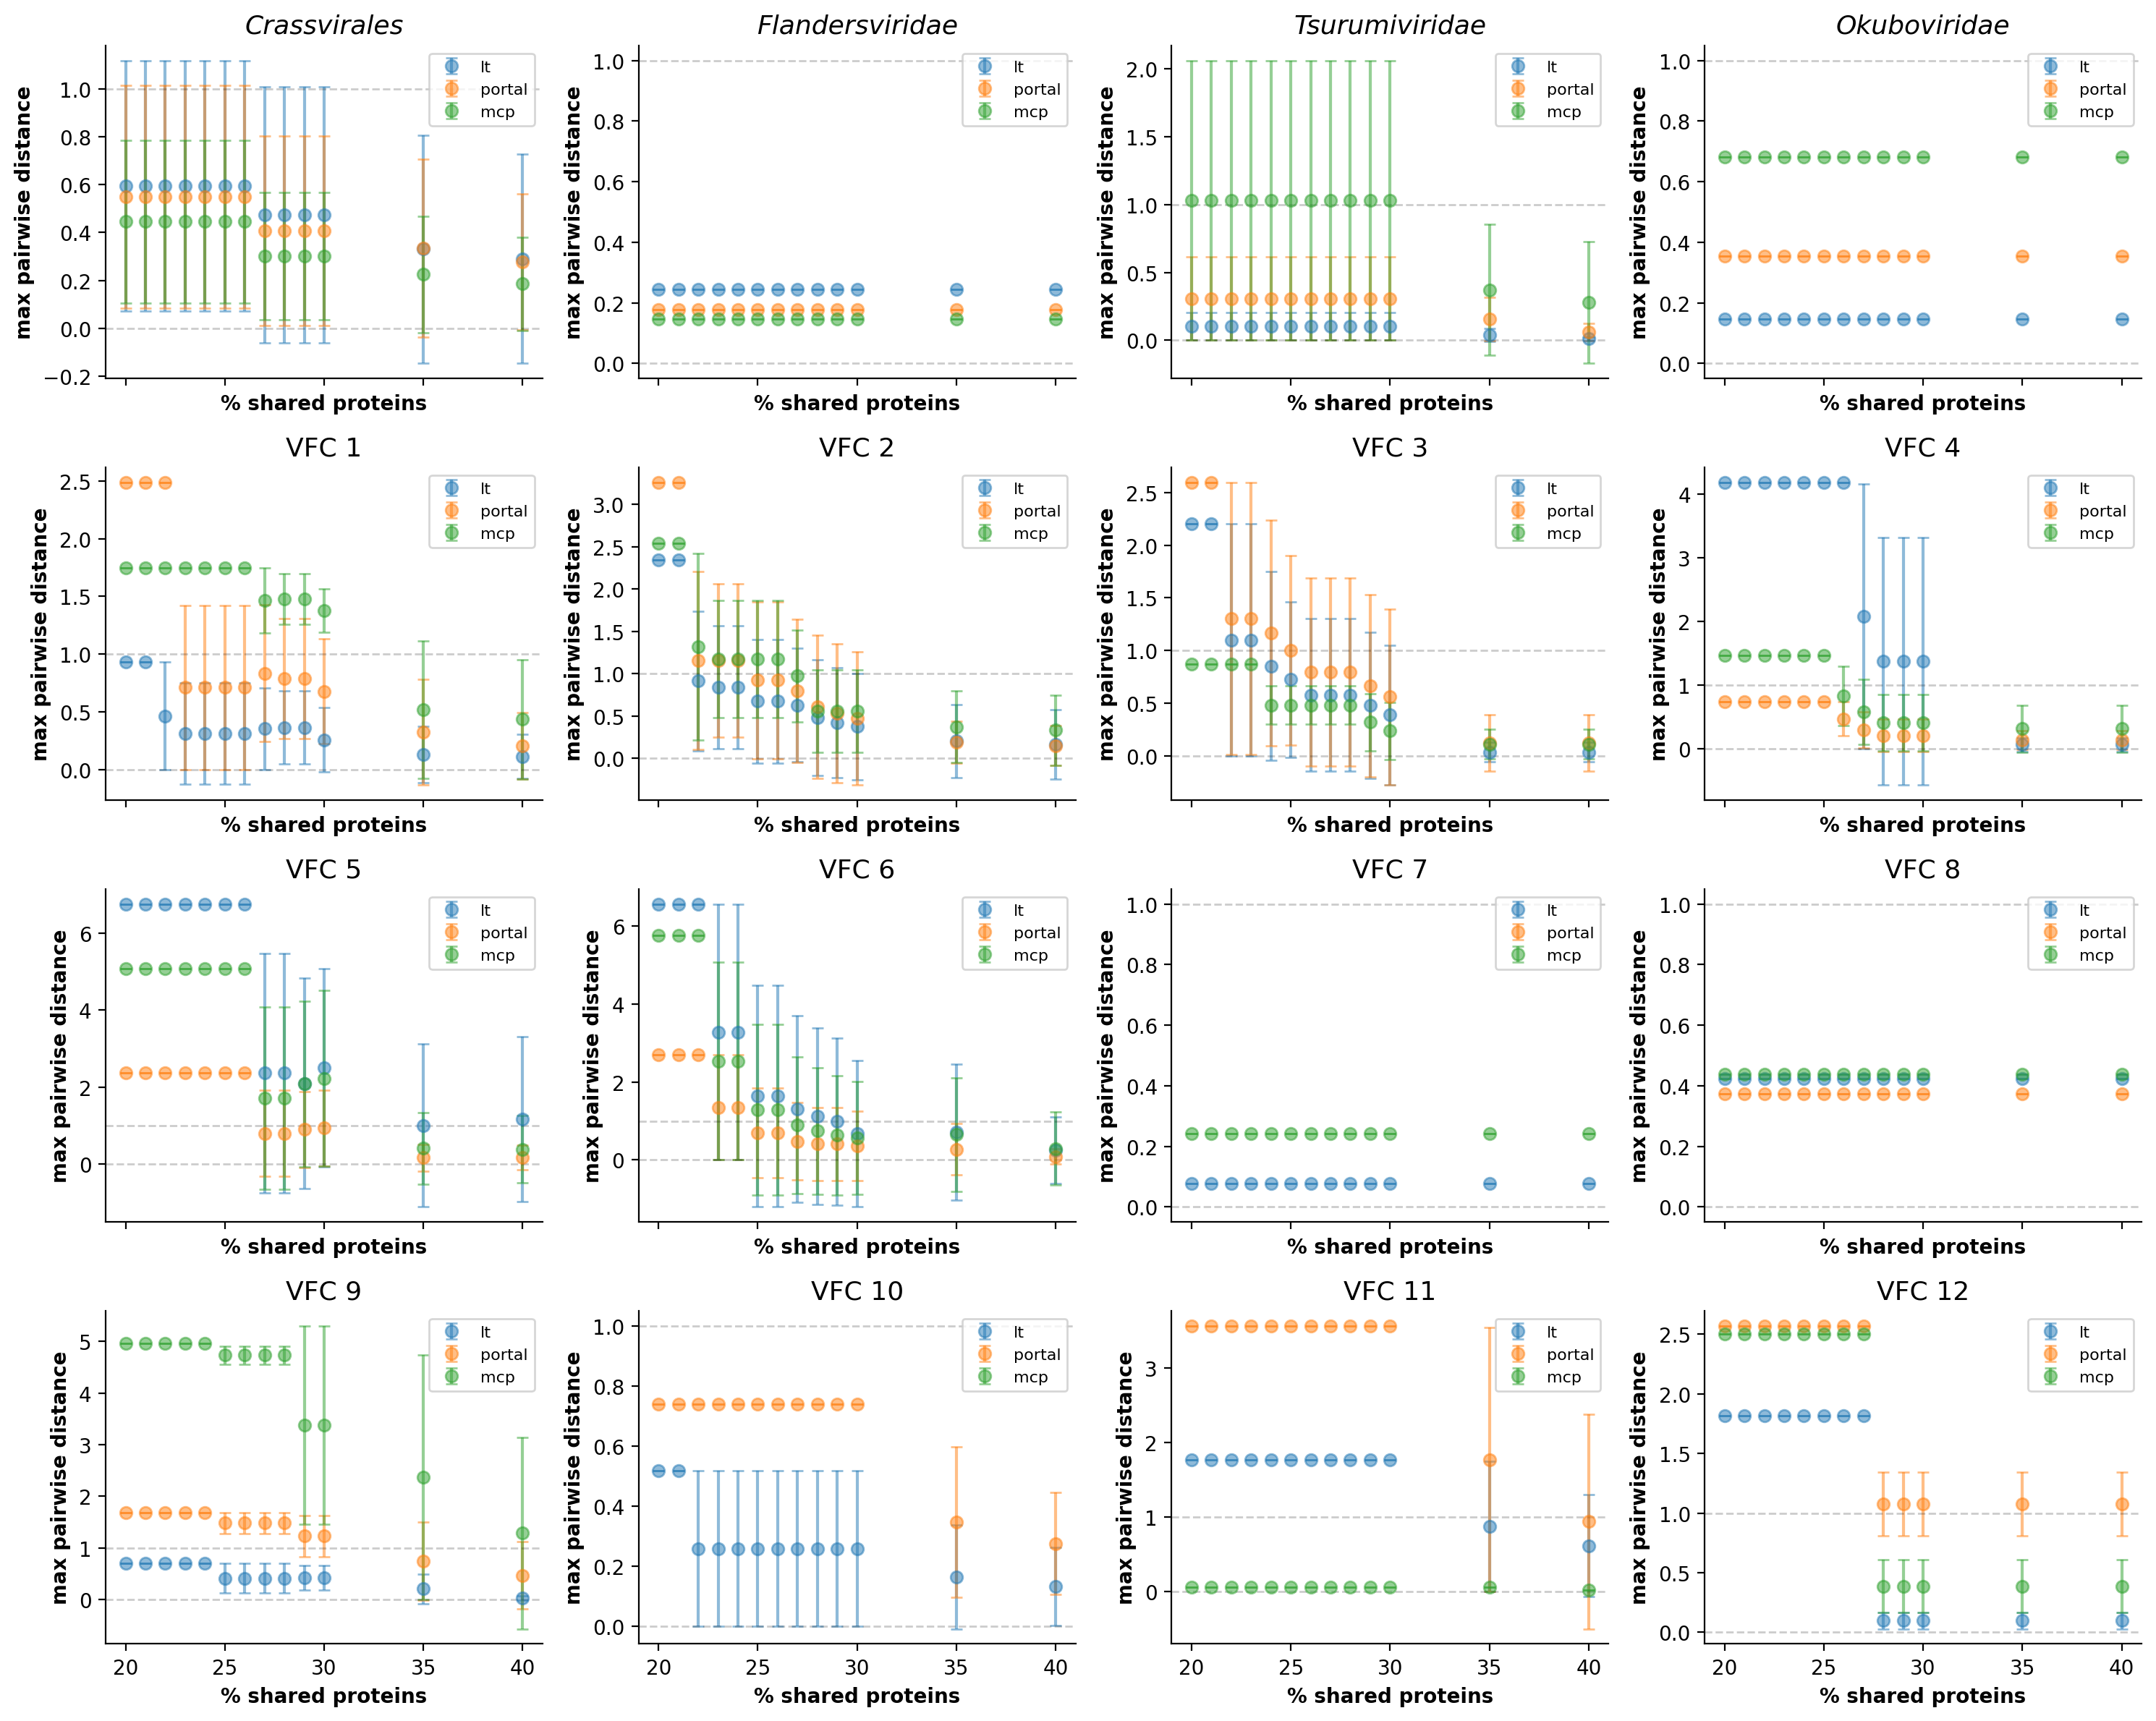

In [3]:
fig, axes = plt.subplots(4, 4, figsize=(15, 12), dpi=200, sharex=True)
axes = axes.flatten()

for i, (vfc, genepds) in enumerate(vfc_pd_dict.items()):
    ax = axes[i]
    sharedlist = 100 - np.array(dlist)
    
    # plot mean and standard deviation for each gene
    for gene, subvc_pds in genepds.items():
        mean_values = [np.mean(pds) for pds in subvc_pds]
        std_values = [np.std(pds) for pds in subvc_pds]
        sem_values = [np.std(pds)/np.sqrt(len(pds)) for pds in subvc_pds]
        mean_values = np.array(mean_values)
        std_values = np.array(std_values)
        sem_values = np.array(sem_values)

        ax.errorbar(sharedlist, mean_values, yerr=std_values, fmt='o', alpha=0.5, capsize=3, label=gene)

    ax.axhline(y=0, color='black', linestyle='--', alpha=0.2, linewidth=1)
    ax.axhline(y=1, color='black', linestyle='--', alpha=0.2, linewidth=1)

    if vfc.startswith('VFC'):
        ax.set_title(vfc, fontsize=13)
    else:
        ax.set_title(vfc, fontsize=13, fontstyle='italic')
    ax.set_xlabel('% shared proteins', fontweight='bold')
    ax.set_ylabel(f'max pairwise distance', fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
sns.despine()